In [31]:
import pandas as pd

# For local/Colab execution
df2 = pd.read_csv('q2_customers.csv')
df2.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [32]:
# For GitHub submission (relative path)
# df2 = pd.read_csv('../data/q2_customers.csv')

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df2)

### Data Scaling

All features were scaled using StandardScaler.

Scaling is important because K-Means uses distance-based calculations, and unscaled data can bias the results.

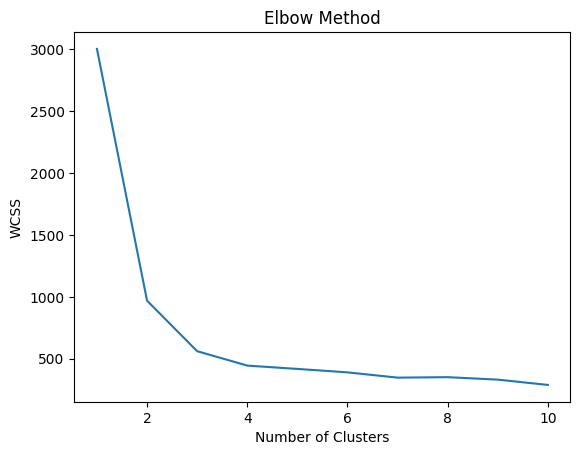

In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

### Elbow Method

The elbow plot is used to determine the optimal number of clusters.

The curve starts to flatten at **K = 3**, indicating that 3 clusters is the optimal choice.

In [35]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df2['cluster'] = clusters
df2.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [36]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df2.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


### Cluster Interpretation

The clusters represent distinct customer segments based on their behavioral patterns and feature values:

- Cluster 0: Customers with relatively higher values across key features, indicating high engagement or high-value customers  
- Cluster 1: Customers with lower feature values, representing low engagement or low-value customers  
- Cluster 2: Customers with moderate values across features, representing average or mid-level customers  

These segments can help businesses design targeted marketing strategies, improve customer retention, and optimize resource allocation.

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [38]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df2.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


### PCA Interpretation

Principal Component Analysis (PCA) reduces dimensionality while retaining most of the variance.

- PC1 captures the maximum variance
- PC2 captures the second highest variance

This helps visualize high-dimensional data in 2D space.

### Explained Variance

The explained variance ratio shows how much information is retained by each principal component.

Higher values indicate more important components.

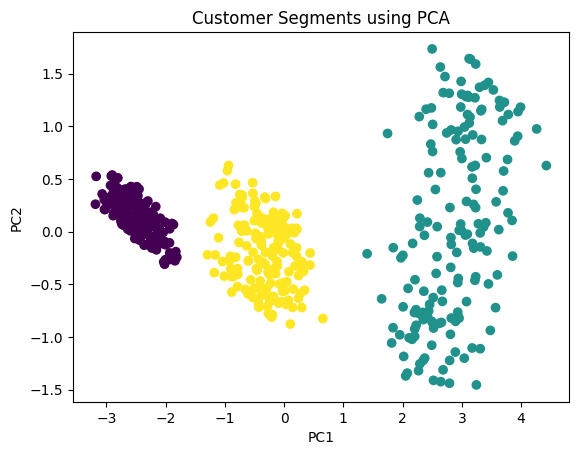

In [39]:
plt.scatter(pca_components[:, 0], pca_components[:, 1], c=clusters)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments using PCA")
plt.show()

### Cluster Visualization

The scatter plot shows clear separation between clusters in PCA-reduced space.

This indicates that K-Means has effectively grouped similar data points.

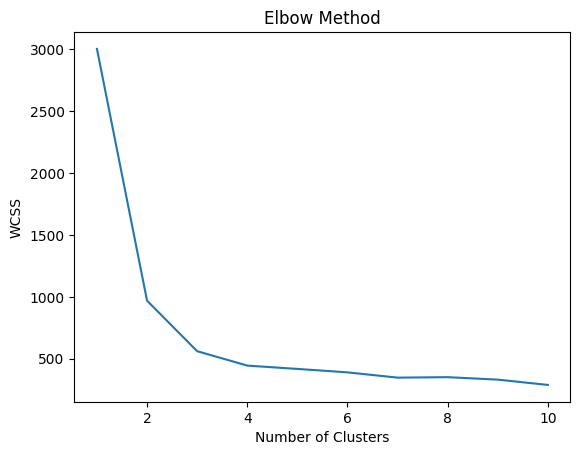

In [40]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

### Elbow Method

The elbow plot is used to determine the optimal number of clusters.

From the graph, there is a sharp decrease in WCSS up to K = 3, after which the curve starts to flatten.

Therefore, the optimal number of clusters is **K = 3**.